# Analysing Pharma Sales Data

In this project I am going to anylize pharmaceutical sales data and answer questions using pandas, matplotlib and seaborn (although seaborn is not listed as a tool in the task, it is very usefull in combination with matplotlib). I will focus only on salesdaily.csv file.

First let's import libraries I need

In [277]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

Now load the dataset and see what I am working with:

In [278]:
sales_daily = pd.read_csv('data/salesdaily.csv')
sales_daily.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [279]:
sales_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


I have categories of drugs:

1. M01AB - Anti-inflammatory and antirheumatic products, non-steroids, Acetic acid derivatives and related substances
2. M01AE - Anti-inflammatory and antirheumatic products, non-steroids, Propionic acid derivatives
3. N02BA - Other analgesics and antipyretics, Salicylic acid and derivatives
4. N02BE/B - Other analgesics and antipyretics, Pyrazolones and Anilides
5. N05B - Psycholeptics drugs, Anxiolytic drugs
6. N05C - Psycholeptics drugs, Hypnotics and sedatives drugs
7. R03 - Drugs for obstructive airway diseases
8. R06 - Antihistamines for systemic use

and dates in which they were sold.

This is almost cleaned dataset so I will only focus on answering questions:

1. On which day of the week is the second drug (M01AE) most often sold?

2. Which three drugs have the highest sales in January 2015, July 2016, September 2017.

3. Which drug has sold most often on Mondays in 2017?

4. Are respiratory drugs (R03) sold more during specific months?

5. What medicine sales may be in October 2019?

But first im going to drop hours column as it is the sum of every hour in the day

In [280]:
sales_daily.drop('Hour', axis=1, inplace=True)

## 1. On which day of the week is the second drug (M01AE) most often sold?

What I will do is group the data by day of the week then take only second drug and use a sum() method

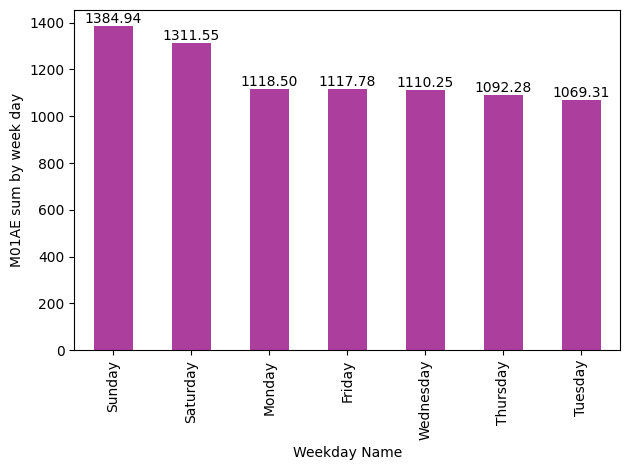

In [281]:
m01ae_mean = sales_daily.groupby('Weekday Name')['M01AE'].sum().sort_values(ascending=False)
ax = m01ae_mean.plot(kind='bar', color="#AC3E9D")
plt.ylabel('M01AE sum by week day')

for container in ax.containers:
    ax.bar_label(container,fmt='%.2f')

plt.tight_layout()

It is visable that on weekends, especially on Sundays drugs listed in category M01AE are sold more often. In this category there are drugs like ibuprofen. I can't tell what are the causes, if there are any. My sugestion would be that people tend to party on weekends and to get back on feed sometimes they need something like ibuprofen. That could be the reason.

## 2. Which three drug categories have the highest sales in January 2015, July 2016, September 2017.

I will split this dataset into 3 sections and look for those drugs by the sum method

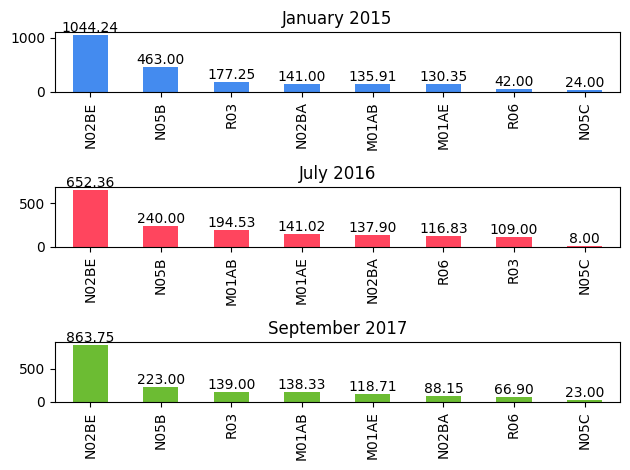

In [282]:
only_sale_data = sales_daily.drop(['Month','Year','datum','Weekday Name'], axis=1)

jan2015 = only_sale_data[(sales_daily['Year']== 2015) & (sales_daily['Month']== 1)]
july2016 = only_sale_data[(sales_daily['Year']== 2016) & (sales_daily['Month']== 7)]
sept2017 = only_sale_data[(sales_daily['Year']== 2017) & (sales_daily['Month']== 9)]

jan2015 = jan2015.sum().sort_values(ascending=False)
july2016 = july2016.sum().sort_values(ascending=False)
sept2017 = sept2017.sum().sort_values(ascending=False)

fig, axes = plt.subplots(3,1)

jan2015.plot(kind='bar', ax= axes[0], color="#448BEF")
axes[0].set_title('January 2015')

july2016.plot(kind='bar', ax= axes[1], color="#FF455E")
axes[1].set_title('July 2016')

sept2017.plot(kind='bar', ax= axes[2], color="#6CBC33")
axes[2].set_title('September 2017')

for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')

plt.tight_layout()

In January we have:
1. NO2BE
2. NO5B
3. RO3

In July:
1. NO2BE
2. NO5B
3. MO1AB

In September:
1. NO2BE
2. NO5B
3. RO3


The domination of NO2BE might be caused by fact that this category cointains things like aspirin, there are drugs that are cheap and could be bought without prescription making them easily avaiable.


## 3. Which drug has sold most often on Mondays in 2017?

I will sort original dataset by year == 2017 and select only Mondays

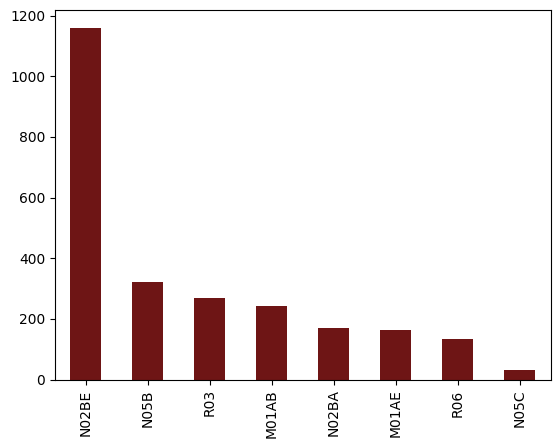

In [283]:
Mondays2017 = only_sale_data[(sales_daily['Year']==2017) & (sales_daily['Weekday Name']=='Monday')]

Mondays2017_sum = Mondays2017.sum().sort_values(ascending=False)

ax = Mondays2017_sum.plot(kind='bar', color="#6E1515")


Also a NO2BE category, nothing unusual.

## 4. Are respiratory drugs (R03) sold more during specific months?

I will need to groub my dataset by a month, then choose only drug category I want, and sum everything up

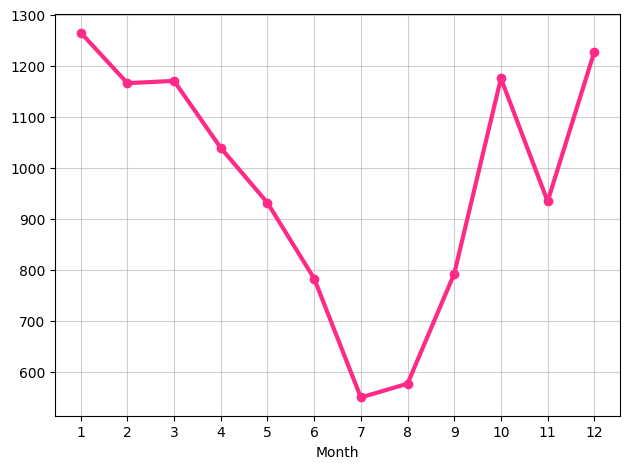

In [284]:
ro3_sales_monthly = sales_daily.groupby('Month')['R03'].sum()
ax = ro3_sales_monthly.plot(kind='line', marker='o', markersize='6', linewidth=3, color="#FF2A86")

plt.grid(True, alpha=0.6)
plt.xticks(range(1,13))
plt.tight_layout()

There is a clear diffrence in months 1-3, 10, 12 and 4-9, 11. This is a respiratory drug, so the diffrence may be coused by a temperature, lungs might be more exposed to harm in colder seasons. There would be exception to this, November (11) has much lower outcome than neighbouring months. That's why there could be another explanation

## 5. What medicine sales may be in October 2019?

I need to establish what my model is going to work on. I need to predict the sales in October, for that I need total sales from ealier months (y). Then I am going to use shift method and move for 1 and 12 months the data (X), That way I will achieve data for my model

In [285]:
#importing my model I am going to use in this prediction
from sklearn.linear_model import LinearRegression
#importing my test to measure wether the model did a good job
from sklearn.metrics import mean_absolute_error

#Sorting and summing by each month in each year, then adding a column of total value in each row
monthly = sales_daily.groupby(['Year','Month']).sum()[['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']]
monthly['Total'] = monthly.sum(axis=1)

#Sorting values by year and month if they were mixed and droping old index
monthly.reset_index(inplace=True)
monthly.sort_values(['Year', 'Month']).reset_index(drop=True, inplace=True)

monthly['Total_shift_1'] = monthly['Total'].shift(1)
monthly['Total_shift_12'] = monthly['Total'].shift(12)


#Dropping every empty row, beacuse model won't tolerate those
monthly.dropna(inplace=True)

#Chosing trainging and testing part
train = monthly[monthly['Year'] <= 2018]
test = monthly[monthly['Year'] == 2019]

features = ['Total_shift_1','Total_shift_12']

X_train = train[features]
y_train = train['Total']

X_test = test[features]
y_test = test['Total']

#Using model, testing wether it is acurate, we got MAE = 384, at this scale it is quite big, around 20%
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test) 
print(f'Mean absolute error for 2019: {mean_absolute_error(y_test, y_pred):.0f}')


#Choosing the features that are necessary for prediction, so if we want to predict Oct 2019
#I need oct 2018 and sep 2019
oct_2018 = monthly[(monthly['Year'] == 2018) & (monthly['Month'] == 10)]['Total'].values[0]
sep_2019 = monthly[(monthly['Year'] == 2019) & (monthly['Month'] == 9)]['Total'].values[0]

#Predicting October 2019 and printing the final result
X_oct_2019 = np.array([[oct_2018, sep_2019]])  # 2 features so [[ , ]] format
oct_2019_pred = model.predict(X_oct_2019)
print(f'Prediction for October 2019: {oct_2019_pred[0]:.0f}')


Mean absolute error for 2019: 384
Prediction for October 2019: 2051


c:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
